# Tier 4: Federated ML with Trusted Third Party

**CSCI 575 | Privacy-Preserving Record Linkage**

Same logistic regression as Tier 3, but trained via FedAvg across two simulated parties. A trusted third party (TTP) still computes the 8 similarity features; T4 only changes how the model is trained, not what it sees. The T3 → T4 gap measures the cost of federated optimization

### Glossary

- **Federated learning:** Training across multiple parties without centralizing the data. Only model updates (gradients or weights) leave each party.
- **FedAvg (Federated Averaging):** The canonical federated algorithm. Each round: every party trains locally for some epochs, sends the resulting weights; the server averages them and broadcasts the new global weights.
- **TTP (Trusted Third Party):** An entity both parties trust to perform some shared computation. In T4, the TTP computes the 8 similarity features from raw records.
- **Mini-batch:** A small random subset of training examples (here: 512 pairs per step) used to estimate the gradient.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics         import f1_score

from utils import (
    FEATURE_NAMES,
    load_candidates, build_feature_matrix,
    sigmoid, train_locally, fedavg,
    compute_metrics, print_metrics, save_metrics,
    plot_score_distribution,
    save_example_pair_predictions,
)

THRESHOLD = 0.50

# FedAvg parameters
N_PARTIES     = 2
N_ROUNDS      = 100
LOCAL_EPOCHS  = 2
BATCH_SIZE    = 512
LEARNING_RATE = 0.1
RANDOM_SEED   = 42

## Load Data and Build Feature Matrix

The TTP loads both parties' records and computes the plaintext feature matrix. The federated clients below never see raw records.

In [2]:
candidates              = load_candidates()
field_similarity_scores = build_feature_matrix(candidates)

print(f'{len(candidates):,} candidate pairs  '
      f'({candidates["is_match"].sum():,} matches, '
      f'{(~candidates["is_match"]).sum():,} non-matches)')

500,000 candidate pairs  (50,000 matches, 450,000 non-matches)


## Split Across Federated Parties

Same 80/20 test split as Tier 3 (same seed). The training set is partitioned evenly across two simulated clients. Each party's data never leaves its own store; only weight updates are exchanged.

In [3]:
labels = candidates['is_match'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    field_similarity_scores,
    labels,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=labels,
)

X_train_array = X_train.values.astype(np.float64)
y_train_array = y_train.values.astype(np.float64)
X_test_array  = X_test.values.astype(np.float64)
y_test_array  = y_test.values.astype(np.float64)

rng = np.random.default_rng(RANDOM_SEED)
shuffled_indices = rng.permutation(len(X_train_array))
party_splits     = np.array_split(shuffled_indices, N_PARTIES)

parties = [
    (X_train_array[split], y_train_array[split])
    for split in party_splits
]


## FedAvg Training

Each round, each party runs mini-batch SGD on its local data, minimizing the same binary cross-entropy loss as Tier 3. The server then averages the returned weight vectors. Same model, same loss; only the optimizer changes. `train_locally` and `fedavg` live in `utils.py`.

In [4]:
global_weights   = rng.normal(0, 0.01, len(FEATURE_NAMES))
global_intercept = 0.0

for round_number in range(1, N_ROUNDS + 1):
    local_results = [
        train_locally(party_X, party_y, global_weights, global_intercept,
                      LOCAL_EPOCHS, BATCH_SIZE, LEARNING_RATE, rng)
        for party_X, party_y in parties
    ]
    global_weights, global_intercept = fedavg(local_results)

    if round_number % 20 == 0 or round_number == N_ROUNDS:
        preds = (sigmoid(X_test_array @ global_weights + global_intercept) >= THRESHOLD).astype(int)
        print(f'Round {round_number:3d}/{N_ROUNDS}: test F1 = {f1_score(y_test_array, preds):.4f}')

learned_coefficients = pd.Series(global_weights, index=FEATURE_NAMES).sort_values(ascending=False)

print('\nLearned coefficients:')
print(learned_coefficients.round(3).to_string())

Round  20/100: test F1 = 0.9880


Round  40/100: test F1 = 0.9882


Round  60/100: test F1 = 0.9935


Round  80/100: test F1 = 0.9950


Round 100/100: test F1 = 0.9953

Learned coefficients:
state             5.739
zip_code          5.120
phone             4.490
last_name         3.181
first_name        3.152
street_address    2.644
email             0.669
date_of_birth     0.081


## Predict on All Candidates

Probabilities for every pair so the comparison notebook can look up the example pairs. Metrics use only the 20% test split.

In [5]:
all_probabilities = sigmoid(field_similarity_scores.values @ global_weights + global_intercept)

candidates['match_probability'] = all_probabilities
candidates['predicted_match']   = (candidates['match_probability'] >= THRESHOLD).astype(int)

test_candidates = candidates.loc[X_test.index]

(test_candidates[['rec_id_a', 'rec_id_b', 'is_match', 'match_probability', 'predicted_match']]
    .round({'match_probability': 3})
    .head())

,rec_id_a,rec_id_b,is_match,match_probability,predicted_match
84492,16243,45003,False,0.001,0
282042,4223,18009,False,0.001,0
478886,21025,48009,False,0.001,0
263682,40414,32578,False,0.000,0
43310,43310,43310,True,0.395,0


## Evaluate

In [6]:
metrics = compute_metrics(
    tier_name        = 'T4_federated_ttp',
    true_labels      = test_candidates['is_match'].astype(int),
    predicted_labels = test_candidates['predicted_match'],
    scores           = test_candidates['match_probability'],
    threshold        = THRESHOLD,
    n_pairs          = len(test_candidates),
)
print_metrics(metrics)

Precision : 0.9990
Recall    : 0.9917
F1        : 0.9953
AUC-ROC   : 1.0000
Threshold : 0.5
N pairs   : 100,000


## Probability Distribution

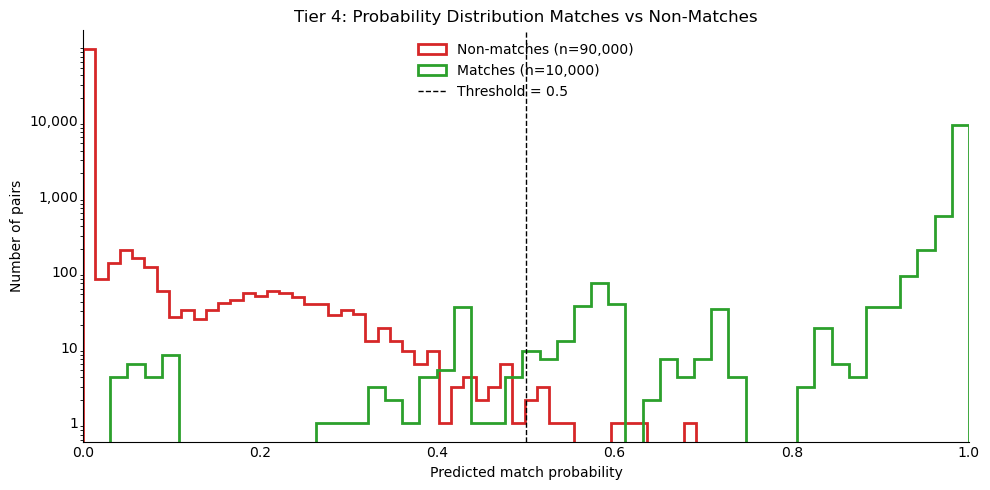

In [7]:
plot_score_distribution(
    match_scores     = test_candidates.loc[test_candidates['is_match'],  'match_probability'],
    non_match_scores = test_candidates.loc[~test_candidates['is_match'], 'match_probability'],
    threshold        = THRESHOLD,
    title            = 'Tier 4: Probability Distribution Matches vs Non-Matches',
    x_label          = 'Predicted match probability',
    filename         = 'tier4_score_distribution.png',
)

## Save Results

In [8]:
save_metrics(metrics, 'tier4_metrics.csv')
save_example_pair_predictions(candidates, 'T4_federated_ttp', 'match_probability', 'tier4_example_predictions.csv')